# Проект: Рынок общественного питания

- Автор: Топорова Е.В.
- Дата: 04.03.2026

## Цели и задачи проекта

Цель: исследовательский анализ рынка общественного питания Москвы для предоставления рекомендаций инвесторам фонда Shut Up and Take My Money по выбору формата, локации и концепции будущего заведения.

Задачи:

1. Проанализировать структуру рынка;
2. Оценить соотношение сетевых и несетевых заведений;
3. Исследовать цены и рейтинги заведений;
4. Найти рыночные ниши;
5. Разработать рекомендации.

## Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».<br>
    и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

## Содержимое проекта

[1. Загрузка данных и знакомство с ними](#1-загрузка-данных)<br>
[2. Предобработка данных](#2-предобработка-данных)<br>
[3. Исследовательский анализ данных](#3-иад)<br>
[4. Итоговый вывод и рекомендации](#4-вывод)

---

<a id="1-загрузка-данных"></a>
## 1 Загрузка данных и знакомство с ними

Загрузим все библиотеки, необходимые для работы.

In [1]:
# !pip install phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik.report import plot_correlation_matrix

Загрузим данные о заведениях общественного питания Москвы.

In [2]:
df_rest_info = pd.read_csv('rest_info.csv')
df_rest_price = pd.read_csv('rest_price.csv')

Познакомимся с данными и изучим общую информацию о них.

In [3]:
df_rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [4]:
df_rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
df_rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [6]:
df_rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### 1.1 Промежуточный вывод

Данные соответствуют заявленному описанию.

В файле `/datasets/rest_info.csv`, содержащем информацию о заведениях общественного питания, наблюдается 8406 строк и 9 столбцов.<br>
2 из 9 столбцов содержат пропуски: hours, seats.<br>
Типы данных:
- столбец chain лучше привести к типу int8 или bool;
- столбец seats (количество посадочных мест) должен быть целочисленным.

В файле `/datasets/rest_price.csv`, содержащем информацию о среднем чеке в заведениях общественного питания, наблюдается 4058 строк и 5 столбцов.<br>
Все столбцы, кроме id, содержат пропуски.<br>
В данном файле типы данных менять не требуется.

### 1.2 Подготовка единого датафрейма

Объединим данные двух датасетов в один, с которым и будем работать.

In [7]:
df = df_rest_info.merge(df_rest_price, on='id', how='left')

Проверим правильность объединения.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [9]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


<a id="2-предобработка-данных"></a>
## 2 Предобработка данных

Подготовим данные к исследовательскому анализу.

Как было сказано ранее, у некоторых столбцов неверно определен тип:
- у chain можно снизить размерность;
- seats определен как float64 вместо int64, так как содержит пропуски.

Проведем преобразование типов.

In [10]:
# Снижение размерности chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

Проверим изменения.

In [11]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Столбец `seats`, вероятно, был определен как float64, так как содержит пропущенные значения.

Изучим пропущенные значения в данных.

In [12]:
(df.isna().sum() / df.shape[0] * 100).sort_values()

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
rating                0.000000
chain                 0.000000
hours                 6.376398
seats                42.957411
avg_bill             54.603854
price                60.563883
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Пропущенные значения в столбце `seats` могли возникунуть из-за того, что данные заведения открылись совсем недавно, и информацию не успели собрать, либо из-за того, что некоторые из них работают на вынос, либо же по техническим причинам. Заполнение 42% строк может привести к искажению данных и помешать анализу, а удалять такое количество данных нельзя, поэтому оставим их без изменений. Если мы оставляем данный столбец без изменений, то изменить его тип нет возможномти.

Что касается 4 столбцов, полученных с сервиса Яндекс Бизнес, то пропущенных значений в них больше 10%, их нельзя просто удалить. Так как эти данные носят исключительно справочный характер, оставим их как есть.

Однако, в столбце `hours` всего 6% пропусков. Посмотрим, какие значения он содержит. 

In [13]:
df['hours'].sort_values().unique()

array(['Нет информации',
       'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30',
       'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00',
       ..., 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно',
       'чт-вс 20:00–06:00', nan], dtype=object)

Как мы видим, столбец `hours` уже содержит значение 'Нет информации', поэтому пропущенные значения также можно заполнить данной строкой.

In [14]:
df['hours'] = df['hours'].fillna('Нет информации')

Проверим данные на явные и неявные дубликаты. Для начала исследуем названия и адреса заведений.

In [15]:
# Сохраняем изначальное количество строк
total_rows = df.shape[0]

check_dup = df[['name', 'address', 'chain']].copy()

# Приводим к нижнему регистру и убираем пробелы
check_dup[['name','address']] = check_dup[['name','address']].apply(lambda x: x.str.lower().str.strip())
check_dup['is_dup'] = check_dup.duplicated(subset=['name','address'], keep=False)

dups = check_dup[check_dup['is_dup']].sort_values(['name','address'])
dups


,name,address,chain,is_dup
1430,more poke,"москва, волоколамское шоссе, 11, стр. 2",0,True
1511,more poke,"москва, волоколамское шоссе, 11, стр. 2",1,True
189,кафе,"москва, парк ангарские пруды",0,True
215,кафе,"москва, парк ангарские пруды",0,True
2211,раковарня клешни и хвосты,"москва, проспект мира, 118",0,True
2420,раковарня клешни и хвосты,"москва, проспект мира, 118",1,True
3091,хлеб да выпечка,"москва, ярцевская улица, 19",1,True
3109,хлеб да выпечка,"москва, ярцевская улица, 19",0,True


В данных обнаружены потенциальные неявные дубликаты. Изучим их подробнее.

In [16]:
df[df['name'].str.lower()=='more poke']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
6088,1cd73aca53414d65a7744da3d1c93832,More Poke,ресторан,"Москва, Духовской переулок, 19",Южный административный округ,"ежедневно, 10:00–22:00",4.4,1,NaN,NaN,NaN,NaN,NaN


Так как у двух строк ресторана More Poke совпадают все ячейки, кроме hours и chain, то они могут являться неявными дубликатами. Возможно, раньше это было несетевое заведение, но потом оно расширилось, а режим работы поменялся. Удалим первое вхождение.

In [17]:
df[(df['address'].str.lower()=='москва, парк ангарские пруды') & (df['name'].str.lower()=='кафе')]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,Кафе,кафе,"Москва, парк Ангарские Пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,Кафе,кафе,"Москва, парк Ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN


У данного заведения также совпадают все ячейки. Возможно, у него изменился график работы, поэтому будем считать первую строку дубликатом и удалим ее.

In [18]:
df[df['name'].str.lower()=='раковарня клешни и хвосты']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни и Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,Раковарня Клешни и хвосты,"бар,паб","Москва, Братиславская улица, 12",Юго-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40.0,средние,Цена бокала пива:150–250 ₽,NaN,NaN


Такая же ситуация, как и спервым заведением. Удалим первую строку.

In [19]:
df[df['name'].str.lower()=='хлеб да выпечка']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,Нет информации,4.1,0,276.0,NaN,NaN,NaN,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,Хлеб да Выпечка,кофейня,"Москва, Каширское шоссе, 61Г",Южный административный округ,"ежедневно, 09:00–22:00",4.5,1,NaN,NaN,NaN,NaN,NaN


С заведением Хлеб да Выпечка ситуация несколько сложнее. Возможно, это заведение сочетает в себе и кафе, и булочную, потому было записано дважды. При этом, есть третье заведение, относящееся, скорее всего, к той же сети. Удалим первую строку, чтобы оптимизировать процесс, так как в остальных заведениях было решено также удалить первое вхождение. Но первая содержит больше информации (часы работы и chain = 1), предварительно сохраним эти данные.

In [20]:
df.loc[df['id'] == 'd3116844e4e048f99614eb30be3214e0', 'chain'] = 1
df.loc[df['id'] == 'd3116844e4e048f99614eb30be3214e0', 'hours'] = 'ежедневно, 09:00–22:00'

df['name_norm'] = df['name'].str.lower().str.strip()
df['address_norm'] = df['address'].str.lower().str.strip()
df = df.drop_duplicates(subset=['name_norm','address_norm'], keep='first')

Проверим также `district` и `category` на наличие неявных дубликатов.

In [21]:
for column in ['district','category']:
    display(f'Уникальные значения в столбце {column}:')
    display(df[column].str.lower().sort_values().unique())
    display()

'Уникальные значения в столбце district:'

array(['восточный административный округ',
       'западный административный округ',
       'северный административный округ',
       'северо-восточный административный округ',
       'северо-западный административный округ',
       'центральный административный округ',
       'юго-восточный административный округ',
       'юго-западный административный округ',
       'южный административный округ'], dtype=object)

'Уникальные значения в столбце category:'

array(['бар,паб', 'булочная', 'быстрое питание', 'кафе', 'кофейня',
       'пиццерия', 'ресторан', 'столовая'], dtype=object)

В столбцах `district` и `category` дубликатов не обнаружено.

In [22]:
df.duplicated().sum()

0

Полные дубликаты в данных отсутствуют.

Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [23]:
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

df[['hours', 'is_24_7']]

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
...,...,...
8401,"ежедневно, 09:00–02:00",False
8402,"ежедневно, 08:00–22:00",False
8403,"ежедневно, круглосуточно",True
8404,"ежедневно, круглосуточно",True


---

### 2.1 Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

In [24]:
final_row_count = df.shape[0]

count_abs = total_rows - final_row_count
count_rel = (total_rows - final_row_count) / total_rows * 100

count_abs, count_rel

(4, 0.04758505829169641)

В результате предобработки данных было выполнено следующее:
1. Снижена размерность `chain` с int64 до int8;
2. Пропуски в `hours` заменены на значение 'Нет информации';
3. Удалены 4 неявных дубликата;
4. Добавлен столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7.

<a id="3-иад"></a>
## 3 Исследовательский анализ данных


### 3.1 Задача 1

Исследуем количество объектов общественного питания по каждой категории заведений.

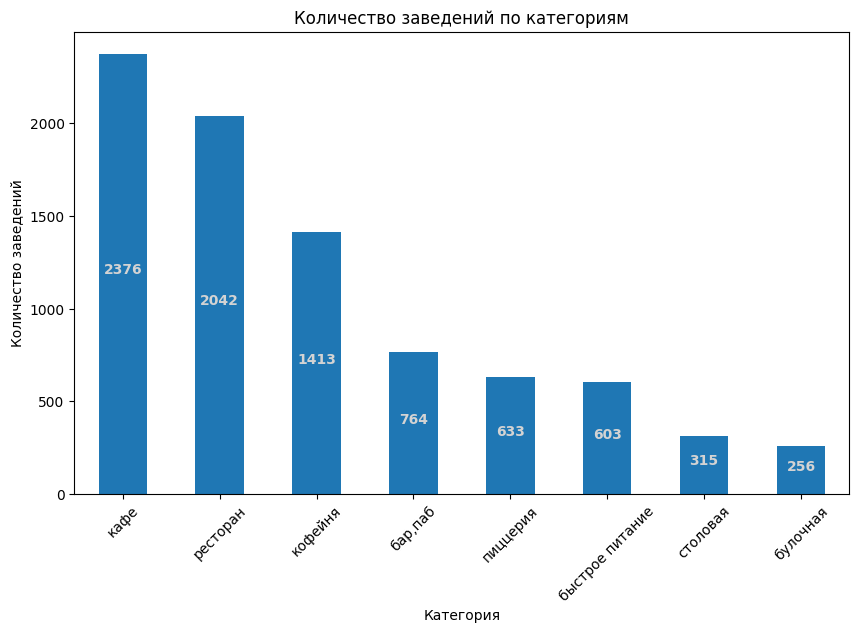

In [25]:
def add_labels(series):
    for i, v in enumerate(series):
        plt.text(i, v // 2, v, ha='center', color='lightgray', fontweight='bold')
        
counts = df['category'].value_counts()

counts.plot(kind='bar',
            title='Количество заведений по категориям',
            legend=False,
            ylabel='Количество заведений',
            xlabel='Категория',
            rot=45,
            figsize=(10, 6))

add_labels(counts)
plt.show()

В результате мы видим, что наибольшее количество заведений представлено в категории 'кафе' (2 376 заведений), на втором месте 'ресторан' (2 042), а на третьем 'кофейня' (1 413). 'Столовая' и 'булочная', напротив, занимают последние места с 315 и 256 заведениями соответственно.

---

### 3.2 Задача 2

Исследуем распределение количества заведений по административным районам Москвы. 

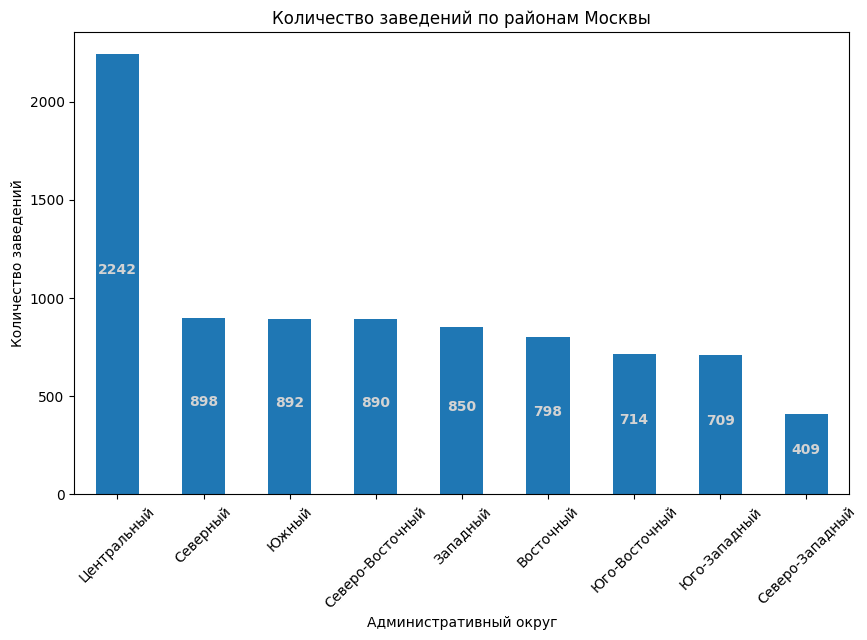

In [26]:
# Создаем новый столбец с сокращенными названиями районов
df['district_short'] = df['district'].str.replace(' административный округ', '')

counts_district = df['district_short'].value_counts()

# Используем сокращенные названия для визуализации
counts_district.plot(kind='bar',
                     title='Количество заведений по районам Москвы',
                     legend=False,
                     ylabel='Количество заведений',
                     xlabel='Административный округ',
                     rot=45,
                     figsize=(10, 6))

add_labels(counts_district)
plt.show()

Среди всех районов Москвы Центральный административный округ является явным лидером по количеству заведений и содержит 2 242 заведения. В то время как в остальных районах 700-900 заведений, а в Северо-Западном округе - 409.<br>
Рассмотрим распределение заведений каждой категории в Центральном округе.

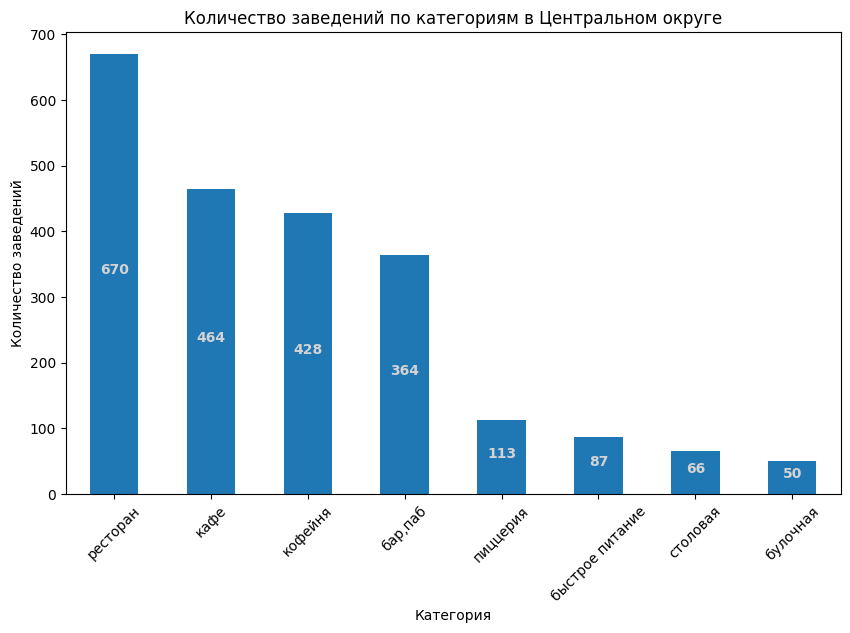

In [27]:
counts_central = df[df['district_short']=='Центральный']['category'].value_counts()

counts_central.plot(kind='bar',
                    title='Количество заведений по категориям в Центральном округе',
                    legend=False,
                    ylabel='Количество заведений',
                    xlabel='Категория',
                    rot=45,
                    figsize=(10, 6))

add_labels(counts_central)
plt.show()

В Центральном административном округе ситуация несколько отличается от общей картины. На первое место по количеству заведений выходит категория 'ресторан' (607 заведений) вместо 'кафе' (464), которое опускается на второе место. В остальном же все без изменений.

---

### 3.3 Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. 

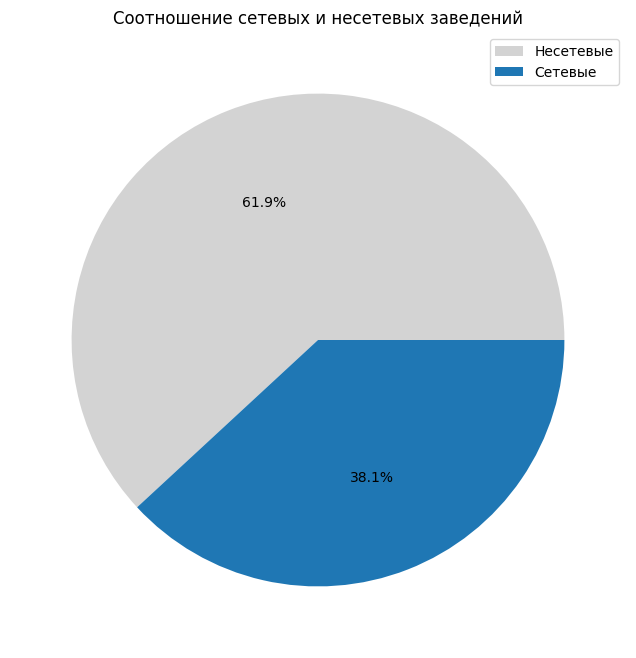

In [28]:
colors = ['lightgray', '#1f77b4']

df['chain'].value_counts().plot(kind='pie',
                                title='Соотношение сетевых и несетевых заведений',
                                legend=True,
                                autopct='%1.1f%%',
                                labels=['Несетевые', 'Сетевые'],
                                labeldistance=None,
                                figsize=(8, 8),
                                ylabel='',
                                colors=colors)

plt.show()

In [29]:
pivot = pd.pivot_table(df,
                       values='chain',
                       index='category',
                       aggfunc=['count', 'mean'])

pivot.columns = ['Всего заведений', 'Доля сетевых (%)']
pivot['Доля сетевых (%)'] = pivot['Доля сетевых (%)'] * 100
pivot = round(pivot.sort_values('Доля сетевых (%)', ascending=False))

pivot

,Всего заведений,Доля сетевых (%)
category,,
булочная,256,61.0
пиццерия,633,52.0
кофейня,1413,51.0
быстрое питание,603,38.0
ресторан,2042,36.0
кафе,2376,33.0
столовая,315,28.0
"бар,паб",764,22.0


В данных гораздо больше несетевых заведений (61.9%), чем сетевых (38.1%).

При этом сетевые заведения чаще встречаются среди таких категорий, как булочная (61%), пиццерия (52%) и кофейня (51%), а несетевые - среди баров (78%), столовых (72%) и кафе (67%).

---

### 3.4 Задача 4

Исследуем количество посадочных мест в заведениях.

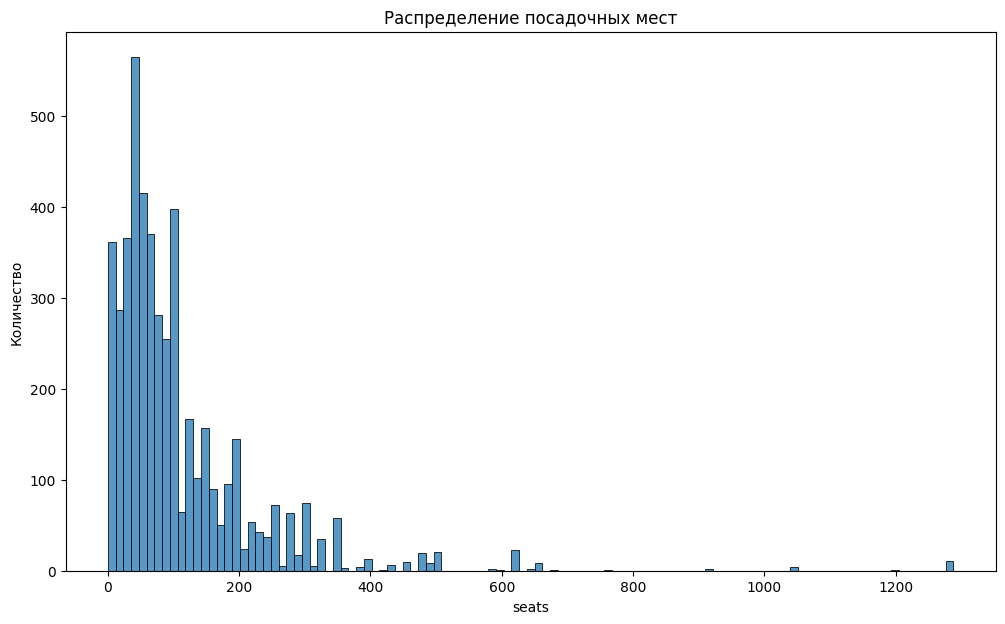

In [30]:
plt.figure(figsize=(12,7))
sns.histplot(data=df, x='seats')
plt.title('Распределение посадочных мест')
plt.ylabel('Количество')
plt.show()

Большинство заведений имеют от 0 до 100 посадочных мест. Заведений с количеством мест больше 200 гораздо меньше.

<AxesSubplot:>

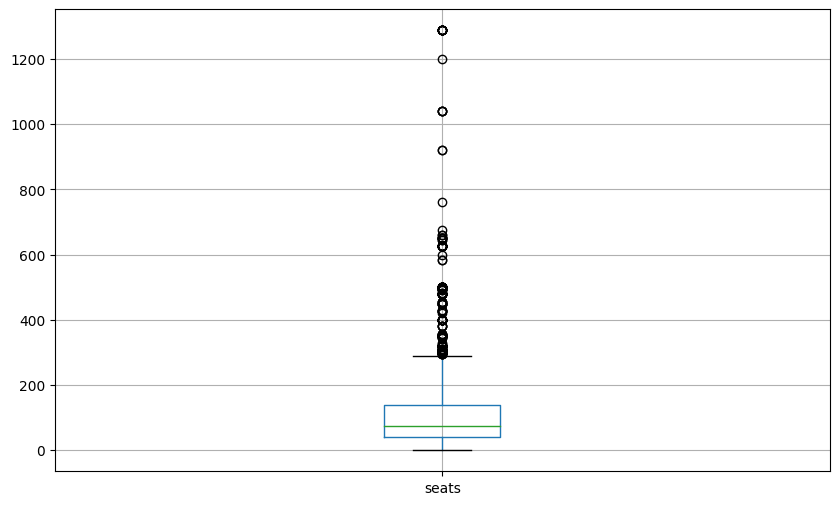

In [31]:
df.boxplot(column='seats', figsize=(10,6))

Объекты с 400+ местами - это, вероятно, единичные случаи. Поэтому на диаграмме размаха они отображаются как выбросы. Однако, лучше проверим данные.

In [32]:
df[df['seats']>=400]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_norm,address_norm,is_24_7,district_short
898,65bac088dfbb4a4e951378291da55c45,ОШ,кафе,"Москва, Ярославское шоссе, 114, корп. 1",Северо-Восточный административный округ,пн-сб 09:00–23:00; вс 10:00–22:00,4.3,1,500.0,NaN,NaN,NaN,NaN,ош,"москва, ярославское шоссе, 114, корп. 1",False,Северо-Восточный
1064,0669ac8b94d04dd9a5c61619c87013ff,Восток,кафе,"Москва, Ярославское шоссе, 19, стр. 1",Северо-Восточный административный округ,"ежедневно, 10:00–18:00",4.3,1,500.0,NaN,NaN,NaN,NaN,восток,"москва, ярославское шоссе, 19, стр. 1",False,Северо-Восточный
1113,6e4040fc95b745de83803aebbd12e1f6,Кафе при АЗС,кафе,"Москва, Ярославское шоссе, 1, корп. 1",Северо-Восточный административный округ,Нет информации,3.5,0,500.0,NaN,NaN,NaN,NaN,кафе при азс,"москва, ярославское шоссе, 1, корп. 1",False,Северо-Восточный
1326,83575e8d81064584ab791877c9d5389c,Нам,"бар,паб","Москва, Ленинградский проспект, 69, стр. 1",Северный административный округ,"ежедневно, 11:00–21:00",4.2,1,625.0,NaN,NaN,NaN,NaN,нам,"москва, ленинградский проспект, 69, стр. 1",False,Северный
1351,9d703f8cdfb7487abbad137d19083ad0,Максима Пицца,пиццерия,"Москва, Ленинградский проспект, 78, корп. 1",Северный административный округ,"пн-пт 09:00–00:00; сб,вс 10:00–00:00",4.3,0,625.0,выше среднего,Средний счёт:1500–1800 ₽,1650.0,NaN,максима пицца,"москва, ленинградский проспект, 78, корп. 1",False,Северный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8110,2a3d26a00489437580c09ff3c9e360bf,Лавка Daily,кафе,"Москва, улица Ленинская Слобода, 19",Южный административный округ,пн-пт 07:30–19:30,4.4,0,450.0,NaN,NaN,NaN,NaN,лавка daily,"москва, улица ленинская слобода, 19",False,Южный
8171,df7865df18e84477a94dd424e372b94d,Монстер Хиллс,ресторан,"Москва, Автозаводская улица, 18",Южный административный округ,"ежедневно, 10:00–22:00",4.0,0,455.0,средние,Средний счёт:600–1200 ₽,900.0,NaN,монстер хиллс,"москва, автозаводская улица, 18",False,Южный
8198,5cc55d53a83547e588d403c5ada1d28f,Милти,быстрое питание,"Москва, улица Ленинская Слобода, 19",Южный административный округ,пн-пт 09:00–19:00,3.8,0,450.0,NaN,NaN,NaN,NaN,милти,"москва, улица ленинская слобода, 19",False,Южный
8237,dbc3aeaf0a8543da966d01ce432d48c9,Pasta Cup & Pinsa,пиццерия,"Москва, Автозаводская улица, 18",Южный административный округ,"ежедневно, 10:00–22:00",3.5,0,455.0,средние,Средний счёт:450–700 ₽,575.0,NaN,pasta cup & pinsa,"москва, автозаводская улица, 18",False,Южный


Теперь видно, что количество мест 400 и более, вероятно, является ошибкой в данных. Во-первых, кафе при АЗС навряд ли содержит 500 мест. Во-вторых, в заведениях, находящихся по одному адресу, количество мест подозрительно совпадает (Москва, улица Ленинская Слобода, 19; Москва, Автозаводская улица, 18).

In [33]:
pivot_seats = (
    df.pivot_table(values='seats',
                   index='category',
                   aggfunc='median')
      .sort_values('seats')
)

pivot_seats

,seats
category,
булочная,50.0
пиццерия,55.0
кафе,60.0
быстрое питание,65.0
столовая,75.5
кофейня,80.0
"бар,паб",82.0
ресторан,86.0


Наименьшее типичное количество мест наблюдается у булочных (50 мест) и пиццерий (55 мест).<br>
Кафе и заведения быстрого питания имеют медиану 60-65 мест.<br>
Столовые, кофейни и бары обладают большей вместимостью (75-82 места).<br>
Наибольшее типичное число посадочных мест характерно для ресторанов - 86 мест.<br>
Таким образом, прослеживается логичная градация.

---

### 3.5 Задача 5

Исследуем рейтинг заведений.

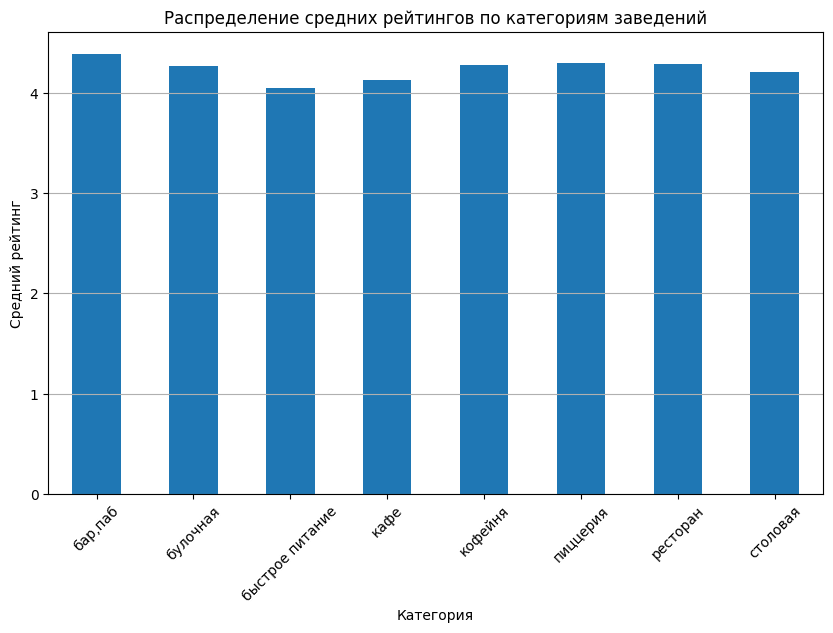

In [34]:
df_unstack = df.groupby('category')['rating'].agg('mean')

df_unstack.plot(kind='bar',
                title='Распределение средних рейтингов по категориям заведений',
                ylabel='Средний рейтинг',
                xlabel='Категория',
                rot=45,
                figsize=(10, 6))

plt.grid(axis='y')
plt.show()

В целом, больших различий в рейтингах заведений из разных категорий не наблюдается.

---

### 3.6 Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.

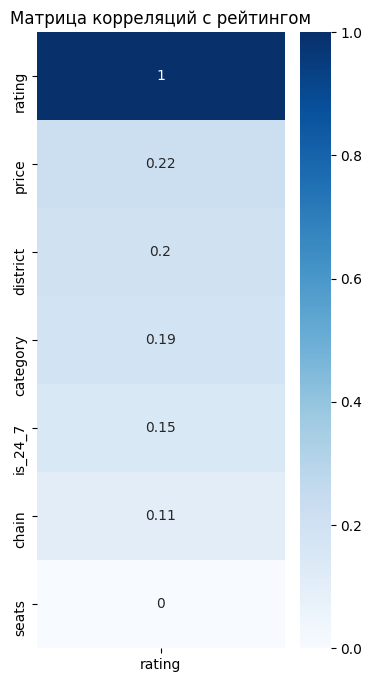

In [35]:
df_corr = df[['rating', 'category', 'district',
              'chain', 'seats', 'price', 'is_24_7']]

# Указываем числовые столбцы явно
interval_cols = ['rating', 'seats']
phik_matrix = df_corr.phik_matrix(interval_cols=interval_cols)

# Оставляем только корреляции с рейтингом
rating_phik = (
    phik_matrix[['rating']].sort_values(by='rating', ascending=False)
)

plt.figure(figsize=(4,8))
sns.heatmap(rating_phik,
            annot=True,
            cmap='Blues')

plt.title('Матрица корреляций с рейтингом')
plt.show()

По матрице корреляций видна небольшая зависимость между столбцами rating и price, коэффициент корреляции phi_k = 0.22.

Проверим эту связь.

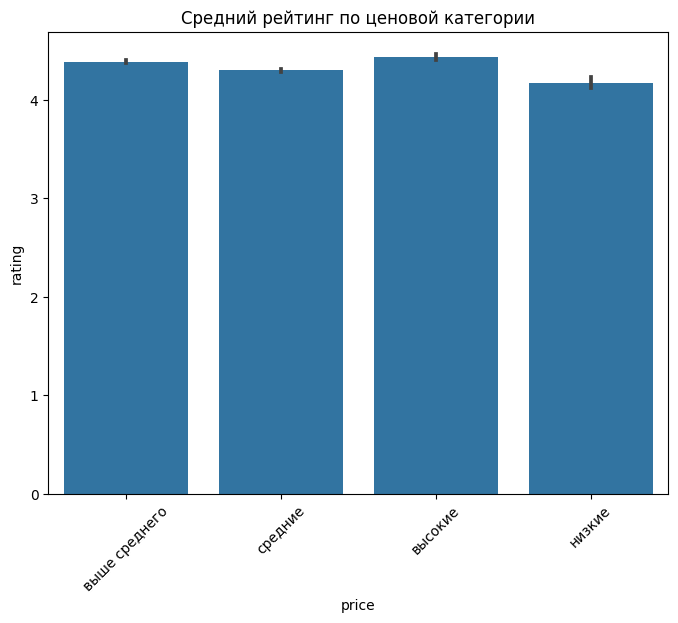

In [36]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='price', y='rating', color='#1f77b4')
plt.xticks(rotation=45)
plt.title('Средний рейтинг по ценовой категории')
plt.show()

Более дорогие заведения в среднем имеют несколько более высокий рейтинг. Однако различия между категориями незначительны: разница между максимальным и минимальным средним рейтингом составляет около 0.25 балла.

Таким образом, связь между ценовой категорией и рейтингом является слабой. Цена оказывает некоторое влияние на оценку, но не является определяющим фактором.

---

### 3.7 Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве (под популярностью будем понимать количество заведений этой сети в регионе).

In [37]:
chain_df = df[df['chain'] == 1]

top_chains = (
    chain_df.groupby('name')
    .agg({'name': 'count', 'rating': 'mean', 'category': 'first'})
    .rename(columns={'name':'count'})
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index()
)

top_chains

,name,count,rating,category
0,Шоколадница,120,4.177500,кофейня
1,Домино'с Пицца,76,4.169737,пиццерия
2,Додо Пицца,74,4.286486,пиццерия
3,One Price Coffee,71,4.064789,кофейня
4,Яндекс Лавка,69,3.872464,ресторан
5,Cofix,65,4.075385,кофейня
6,Prime,50,4.116000,ресторан
7,Хинкальная,44,4.322727,быстрое питание
8,КОФЕПОРТ,42,4.147619,кофейня
9,Кулинарная лавка братьев Караваевых,39,4.394872,кафе


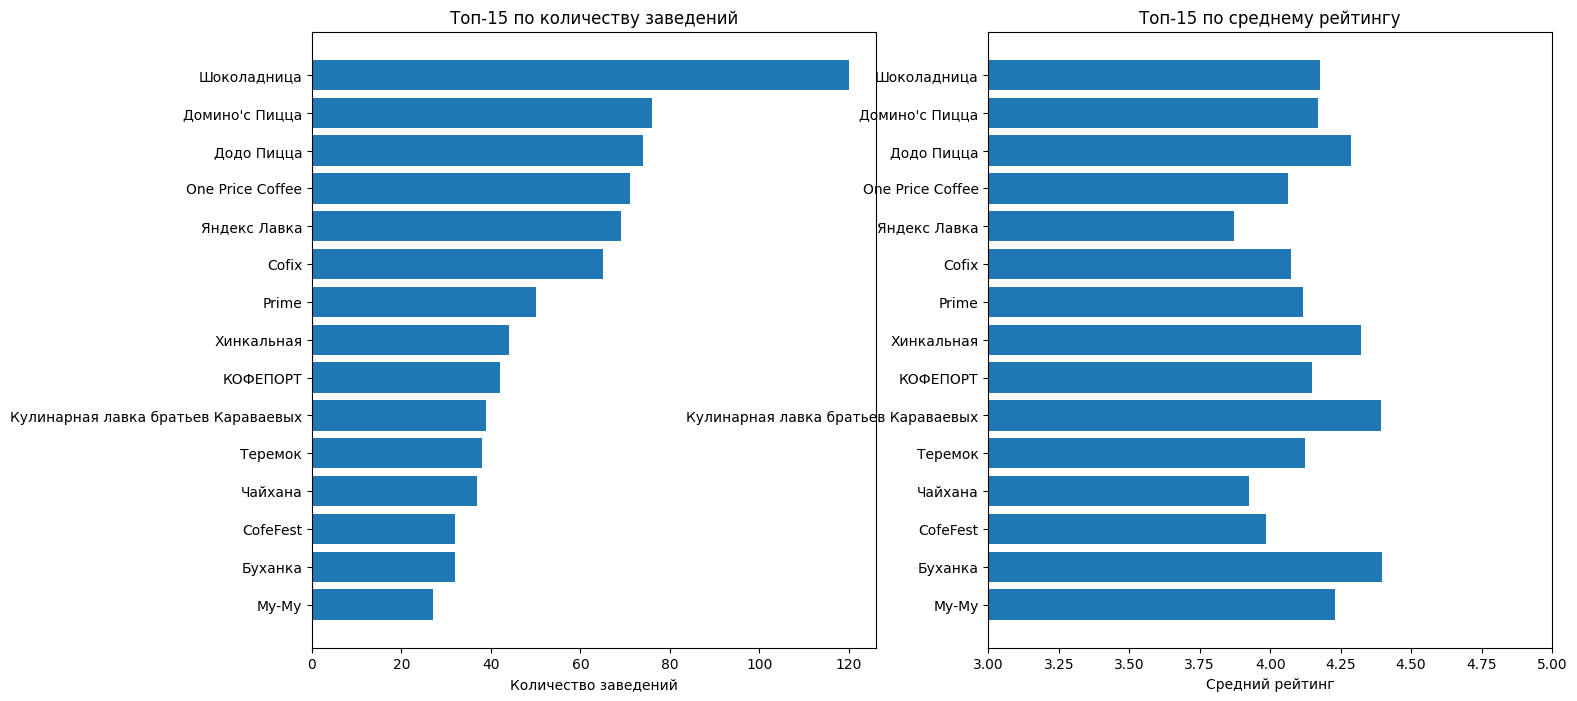

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top_chains['name'], top_chains['count'])
axes[0].set_title('Топ-15 по количеству заведений')
axes[0].set_xlabel('Количество заведений')
axes[0].invert_yaxis()

axes[1].barh(top_chains['name'], top_chains['rating'])
axes[1].set_title('Топ-15 по среднему рейтингу')
axes[1].set_xlabel('Средний рейтинг')
axes[1].set_xlim(3, 5)
axes[1].invert_yaxis()
plt.show()

Самой популярной сетью оказалась кофейня Шоколадница (120 заведений), на втором и третьем местах - пиццерии (76 и 74 заведений). На четвертом - еще одна кофейня (71 заведение).<br>
Сеть быстрого питания оказалась в середине рейтинга.<br>
Все кафе и 1 булочная заняли места ниже середины. 

Однако, также можно заметить, что количество не равно качеству.<br>
Наибольший рейтинг у заведений Буханка и Кулинарная лавка братьев Караваевых, которые занимают места ниже середины по количеству.<br>
Или, например, Яндекс Лавка, занявшая пятое место по количеству, имеет самый низкий рейтинг.

---

### 3.8 Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы.

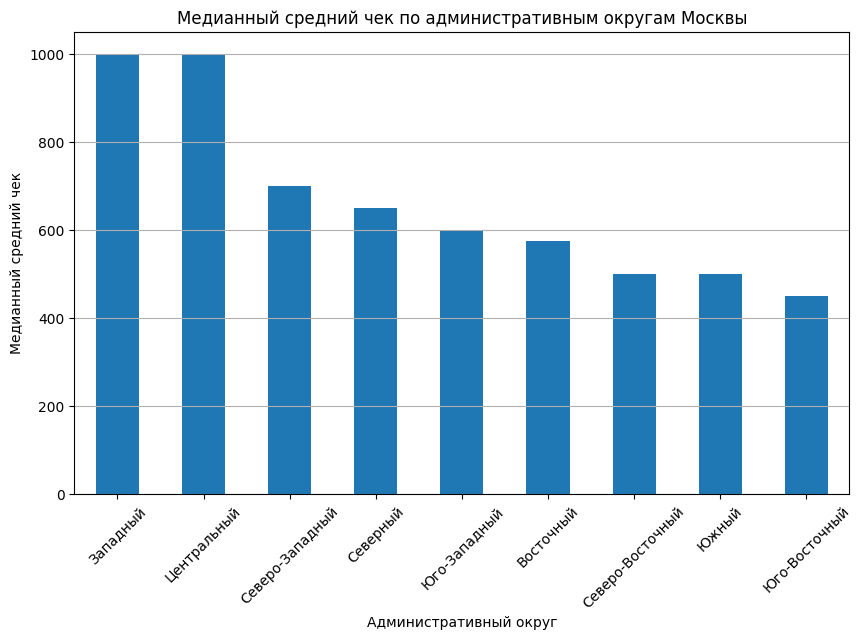

In [39]:
df_bills = df[df['middle_avg_bill'].notna()].copy()

df_bills.groupby('district_short')['middle_avg_bill']\
        .median()\
        .sort_values(ascending=False)\
        .plot(
            kind='bar',
            title='Медианный средний чек по административным округам Москвы',
            ylabel='Медианный средний чек',
            xlabel='Административный округ',
            rot=45,
            figsize=(10,6)
        )

plt.grid(axis='y')
plt.show()

Центральный и Западный округа имеют самый высокий медианный чек (около 1000 р). 

Восточный, Северо-Восточный, Южный и Юго-Восточный округа - самые дешёвые (500-450 р).

---

### 3.9 Промежуточный вывод

1. Наиболее распространенные заведения - кафе, рестораны и кофейни.
2. Центральный административный округ отличается повышенным количеством ресторанов.
3. Несетевых заведений больше, сетевые чаще представлены в маленьких форматах (булочные, пиццерии, кофейни).
4. Размер заведения логично коррелирует с категорией: рестораны и бары больше, булочные и пиццерии меньше.
5. Рейтинг заведения мало зависит от категории, но слегка выше у дорогих заведений.
6. Популярные сети - в основном кофейни и пиццерии; количество не всегда отражает качество.
7. Средний чек выше в центральных и западных округах, ниже - в восточных.

<a id="4-вывод"></a>
## 4 Итоговый вывод и рекомендации

### 4.1 Общий обзор проделанной работы

В ходе анализа были выполнены следующие этапы:
1. Предобработка данных:
- Приведение типа столбца chain к int8, удаление дубликатов.
- Заполнение пропусков в столбце hours значением 'Нет информации'.
- Добавление признака круглосуточной работы is_24_7.
2. Исследовательский анализ данных:
- Структура рынка по категориям заведений.
- Распределение заведений по административным округам Москвы.
- Соотношение сетевых и несетевых заведений.
- Количество посадочных мест и выявление аномалий.
- Рейтинги заведений и их корреляция с другими признаками.
- Средний чек и его зависимость от района и удаленности от центра.
- Анализ популярных сетевых заведений.

### 4.2 Главные выводы исследования
2.1 Структура рынка
- Наиболее распространенные форматы: кафе, рестораны, кофейни.
- Менее распространенные форматы: столовые и булочные.
- В Центральном административном округе рестораны преобладают над кафе, во всех округах вместе - наоборот.

2.2 Сетевые и несетевые заведения
- Несетевых заведений в Москве значительно больше, чем сетевых.
- Чаще всего сетевые заведения встречаются среди булочных, пиццерий и кофеен.
- Чаще всего несетевые - среди баров, столовых и кафе.

2.3 Количество посадочных мест
- Большинство заведений имеют от 0 до 100 мест.
- Аномалии (400+ мест) встречаются редко, вероятно, из-за ошибок ввода.
- Наблюдается логичная градация размера заведения по категории.

2.4 Рейтинг заведений
- Средние рейтинги практически не различаются между категориями (разница примерно 0.25 балла).
- Слабая положительная связь между рейтингом и ценовой категорией (phi_k = 0.22): дорогие заведения немного выше оцениваются, но это не ключевой фактор.

2.5 Популярные сети
- Самая популярная сеть - кофейня Шоколадница (120 заведений).
- Далее пиццерии и другие кофейни.
- Популярность сети не всегда отражает высокое качество (рейтинг).

2.6 Средний чек и локация
- В Центральном и Западном административном округах - самый высокий медианный чек (1000 р).
- В Восточном, Северо-Восточном, Южном и Юго-Восточном округах - самый низкий чек (450–500 р).
- Удаленность от центра Москвы напрямую снижает средний чек.

### 4.3 Рекомендации для инвесторов
Выбор формата заведения:
- Для сетевого формата стоит ориентироваться на категории с наибольшей долей сетевых заведений:
    - булочные - 61% сетевых,
    - пиццерии - 52% сетевых,
    - кофейни - 51% сетевых.
- Для уникального концепта с высокой маржинальностью лучше выбирать категории, где преобладают несетевые (меньше конкуренции со стороны сетей):
    - бары - 78% несетевых,
    - столовые - 72% несетевых,
    - кафе - 67% несетевых.

Выбор локации:
- Центральный и Западный округа - для заведений с высоким средним чеком и премиальной концепцией. Медианный чек в ЦАО и ЗАО составляет около 1000 руб., что вдвое выше, чем в самых доступных округах (450-500 руб.).
- В ЦАО сконцентрировано максимальное количество заведений - 2242, при этом здесь лидируют рестораны (607 против 464 кафе), что говорит о платёжеспособной аудитории, готовой тратить больше.
- Восточный, Северо-Восточный, Южный и Юго-Восточный округа - для демократичных форматов с невысоким средним чеком (450-500 руб.). Здесь целесообразно открывать заведения быстрого питания, булочные, кофейни с ценами ниже среднего.

Концепция заведения:
- Малые форматы (до 55 мест) оптимальны для сетевых точек с упором на вынос или быстрое обслуживание:
    - булочные (медиана 50 мест),
    - пиццерии (медиана 55 мест).
- Форматы средней вместимости (60–82 места) подходят для кафе, кофеен, столовых и баров:
    - кафе и фастфуд - 60-65 мест,
    - столовые, кофейни, бары - 75-82 места.
- Крупные форматы (от 86 мест) - для ресторанов с полноценным обслуживанием (медиана 86 мест). Учитывайте, что заведения с числом мест более 400 встречаются крайне редко и, вероятно, связаны с ошибками данных – такие масштабы нехарактерны для обычных точек.

Ценообразование:
- Средний чек следует планировать исходя из округа:
    - премиальный сегмент - ЦАО и ЗАО (медианный чек 1000 руб.),
    - демократичный - окраины и спальные районы (450–500 руб.).

Связь между ценой и рейтингом слабая (коэффициент корреляции phi_k = 0.22). Разница в среднем рейтинге между разными ценовыми категориями не превышает 0,25 балла. Это значит, что стоимость блюда не является главным фактором успеха - решающую роль играют качество обслуживания, концепция и маркетинг. Даже в самом доступном сегменте можно добиться высоких оценок.

Самые популярные сети по количеству точек:
- 2 кофейни (120 и 71 заведение),
- 2 пиццерии (76 и 74 заведения).

Эти форматы доказали востребованность и могут служить ориентиром для масштабирования. Однако количество не равно качеству: наивысший рейтинг имеют небольшие сети «Буханка» и «Кулинарная лавка братьев Караваевых» (они занимают места ниже середины по числу точек), а «Яндекс Лавка» (5-е место по количеству) демонстрирует самый низкий рейтинг. При выборе формата и локации важно не только копировать лидеров по числу заведений, но и учитывать репутационные риски.